In [ ]:
class MCMC:
    def __init__(self, model, **kwargs) -> None:
        self.model = model
    
    

In [1]:
import re
import emcee
from model import Model
import numpy as np
import matplotlib.pyplot as plt

def line(x,a,b):
    return a*x + b

model = Model.wrap(line, grid_variables=["x"])
print(model)

MODEL NAME: SimpleModel 
FREE PARAMS: 2
GRID VARIABLES: ['x']
N-DIM: 1
------------------------------------------------------------
     NAME            VALUE      IS-FROZEN  BOUNDS              
------------------------------------------------------------
0    a               1.00       No         (-inf, inf)         
1    b               1.00       No         (-inf, inf)         



Text(0, 0.5, 'y')

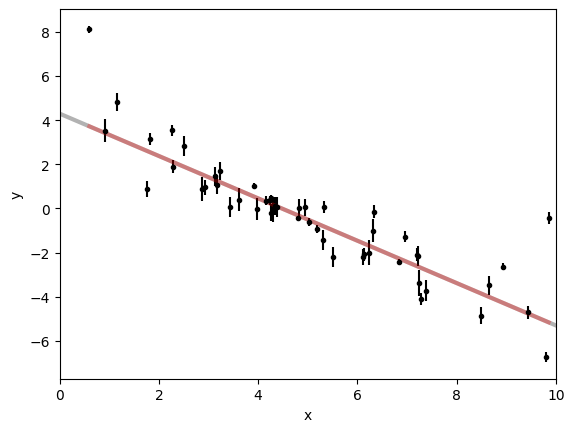

In [2]:


np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = line(x, m_true,b_true)
y_model = model(x, a=m_true, b=b_true)

y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(0, 10, 500)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
plt.plot(x, y_model, "r", alpha=0.3, lw=3)

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [ ]:
def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)